# AgroPlus - Modelo L2 LLP-Co (CRISP-DM)

Notebook dedicado al **modelo de clasificacion de cultivos por proporciones (LLP-Co)** para la capa L2 del ensamble jerarquico de AgroPlus.

**Objetivo:** entrenar y afinar un modelo basado en *La Rosa et al. (2022) - Learning from Label Proportions with Prototypical Contrastive Clustering* sobre la vista minable, usando como prior las proporciones agregadas de la Evaluacion Agropecuaria Municipal (EVA) de Cundinamarca.

**Pipeline:**
1. Preparacion de datos - filtrado a L2 EVA, mascara agricola, soft labels.
2. Bags dinamicos por municipio (sampleo aleatorio cada epoch).
3. Encoder MLP + Prototipos + Sinkhorn-Knopp con restriccion de proporcion.
4. Evaluacion: KL divergence por bag, F1 macro pixel, prototipos.
5. Ajuste de hiperparametros.


---

# PASO 1 — Modelo L2 EVA con LLP-Co

## Objetivo
Entrenar un clasificador a nivel de pixel usando solo proporciones de cultivo por municipio-semestre (etiqueta débil tipo LLP).

**Algoritmo 1 del paper, adaptado a tabular:**
- Encoder MLP: features tabulares → embedding 1024 normalizado L2 (en lugar de ResNet18 sobre patches).
- Augmentaciones: feature dropout (0.2) + ruido gaussiano (σ=0.05) para generar 2 vistas por pixel.
- Prototipos `V` ∈ ℝ^{K × 1024} entrenables.
- Códigos `Q^s, Q^t` por Sinkhorn-Knopp restringidos a `wᵢ` (proporciones EVA del bag).
- Pérdida swap entre las dos vistas (eq. 7-9 del paper).

**Bags:** `(cod_mun, semestre)` → ~1000-2000 bags.


## 1.1 Instalación de dependencias

In [75]:
# Instalacion completa de dependencias del notebook ensamble.
# Cubre: numerico, viz, ML clasico, XGBoost, PyTorch, balanceo, optimizacion bayesiana.
# Nota: para PyTorch CUDA usar el comando especifico de https://pytorch.org/

%pip install -q "numpy>=1.24" "pandas>=2.0" "pyarrow>=14" "matplotlib>=3.8" "seaborn>=0.13" "scikit-learn>=1.4" "xgboost>=2.0" "imbalanced-learn>=0.12" "optuna>=3.6" "optuna-integration[sklearn]>=3.6" "torch>=2.0" "tqdm>=4.66" "nbformat>=5.9" "ipykernel>=6.29"

print("Dependencias instaladas. Reinicia el kernel si pytorch o matplotlib se actualizo.")


Note: you may need to restart the kernel to use updated packages.
Dependencias instaladas. Reinicia el kernel si pytorch o matplotlib se actualizo.


## 1.2 Imports

In [76]:
# Compatibilidad matplotlib >= 3.9: MatplotlibDeprecationWarning fue eliminada.
import matplotlib._api as _mpl_api_compat
if not hasattr(_mpl_api_compat, 'MatplotlibDeprecationWarning'):
    class MatplotlibDeprecationWarning(DeprecationWarning):
        pass
    _mpl_api_compat.MatplotlibDeprecationWarning = MatplotlibDeprecationWarning

# Suppression de warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Stdlib
import os, json, collections, time
from pathlib import Path

# Numericas / DataFrames
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.style.use('ggplot')
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
%matplotlib inline

# Preprocesamiento
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# Splits
from sklearn.model_selection import GroupShuffleSplit

# Metricas
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, log_loss
)

# Modelos clasicos
from xgboost import XGBClassifier
import xgboost as xgb

# PyTorch (LLP-Co)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibilidad
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"NumPy {np.__version__}, Pandas {pd.__version__}, "
      f"PyTorch {torch.__version__} (CUDA={torch.cuda.is_available()}), "
      f"XGBoost {xgb.__version__}")


NumPy 2.4.4, Pandas 3.0.2, PyTorch 2.11.0+cpu (CUDA=False), XGBoost 3.2.0


In [77]:
# --- Dispositivos ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {DEVICE}")

# XGBoost device
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    XGB_DEVICE = 'cuda' if result.returncode == 0 else 'cpu'
except Exception:
    XGB_DEVICE = 'cpu'
XGB_TREE_METHOD = 'hist'
print(f"XGBoost device: {XGB_DEVICE}")


PyTorch device: cpu
XGBoost device: cuda


---
## 2. Comprensión de los Datos

Carga de la vista minable, catálogo y filtrado a las filas L2 EVA con catálogo L2 de 16 clases.

In [78]:
# Rutas locales
DATA_DIR = Path('../vista_minable')
CKPT_DIR = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

DATA_PATH = DATA_DIR / 'vista_minable_full.parquet'
CATALOGO_PATH = DATA_DIR / 'catalogo_cultivos.json'

print(f"Vista minable: {DATA_PATH} ({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"Catalogo:      {CATALOGO_PATH}")


Vista minable: ..\vista_minable\vista_minable_full.parquet (579.3 MB)
Catalogo:      ..\vista_minable\catalogo_cultivos.json


In [79]:
# Cargar vista minable y catalogo
df_raw = pd.read_parquet(DATA_PATH)
print(f"Vista minable: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")

with open(CATALOGO_PATH, 'r', encoding='utf-8') as f:
    catalogo_full = json.load(f)
inv_catalogo_full = {v: k for k, v in catalogo_full.items()}
print(f"Catalogo original: {len(catalogo_full)} clases -> {list(catalogo_full.keys())}")


Vista minable: 4,164,485 filas x 74 columnas
Catalogo original: 19 clases -> ['Papa', 'Cana_Panelera', 'Cafe', 'Maiz', 'Platano', 'Mango', 'Frijol', 'Cacao', 'Arveja', 'Palma', 'Banano', 'Naranja', 'Mora', 'Zanahoria', 'Tomate_Arbol', 'Yuca', 'Habichuela', 'Otros_cultivos', 'No_apto']


In [80]:
# === Catalogo final L2: 16 clases ===
# L2 modela cultivos no-Papa y no-No_apto:
#   - Papa la cubre el modelo L1 (monitoreo UPRA, ground truth pixel-level)
#   - No_apto lo cubre el modelo L3 (proxy SIPRA + NDVI)
# Top-12 originales + 5 nuevos (Mora, Zanahoria, Tomate_Arbol, Yuca, Habichuela)
# que suman ~8% adicional de cobertura de area agricola cundinamarquesa (~85% total).
# Las filas con cultivo no mapeado (Otros_cultivos) reciben cultivo_id_final = argmax(W_L2).
# prob_Papa y prob_No_apto NO entran en W (no estan en CLASES_FINALES).
CLASES_FINALES = [
    'Cana_Panelera', 'Cafe', 'Maiz', 'Platano', 'Mango',
    'Frijol', 'Cacao', 'Arveja', 'Palma', 'Banano', 'Naranja',
    'Mora', 'Zanahoria', 'Tomate_Arbol', 'Yuca', 'Habichuela',
]
catalogo = {c: i for i, c in enumerate(CLASES_FINALES)}
inv_catalogo = {i: c for c, i in catalogo.items()}
K_FINAL = len(CLASES_FINALES)
print(f"Catalogo L2 final: {K_FINAL} clases (Papa -> L1, No_apto -> L3)")
for k, v in catalogo.items():
    print(f"  [{v:2d}] {k}")


Catalogo L2 final: 16 clases (Papa -> L1, No_apto -> L3)
  [ 0] Cana_Panelera
  [ 1] Cafe
  [ 2] Maiz
  [ 3] Platano
  [ 4] Mango
  [ 5] Frijol
  [ 6] Cacao
  [ 7] Arveja
  [ 8] Palma
  [ 9] Banano
  [10] Naranja
  [11] Mora
  [12] Zanahoria
  [13] Tomate_Arbol
  [14] Yuca
  [15] Habichuela


In [81]:
# === Distribucion por nivel de etiquetado ===
fuentes = df_raw['fuente'].value_counts()
print("Pixeles por nivel:")
print(fuentes.to_string())
print()
print("Pixeles por (fuente, cultivo):")
print(df_raw.groupby(['fuente', 'cultivo']).size().unstack(fill_value=0))


Pixeles por nivel:
fuente
eva_municipal    2990171
noapto_proxy      608285
monitoreo         566029

Pixeles por (fuente, cultivo):
cultivo        Arveja  Banano  Cacao    Cafe  Cana_Panelera  Frijol  \
fuente                                                                
eva_municipal  499167   13535  28667  201587          87780  117659   
monitoreo           0       0      0       0              0       0   
noapto_proxy        0       0      0       0              0       0   

cultivo        Habichuela    Maiz  Mango   Mora  No_apto  Otros_cultivos  \
fuente                                                                     
eva_municipal        7797  311172  13269  33062        0         1394887   
monitoreo               0       0      0      0        0           79971   
noapto_proxy            0       0      0      0   608285               0   

cultivo        Palma    Papa  Platano   Yuca  Zanahoria  
fuente                                                   
eva_municipal 

---
## 3. Preparacion de Datos para L2 LLP-Co

Filtrar a `fuente=='eva_municipal'`, construir W_norm (16 clases, sin Papa ni No_apto ni Otros_cultivos),
reclasificar pixeles con argmax=Otros_cultivos via argmax(W_L2), y armar bags por municipio.


In [82]:
# === Filtrar a L2 EVA: mantener pixeles con masa util en 16 clases L2 ===
df_l2 = df_raw[df_raw['fuente'] == 'eva_municipal'].copy()
print(f"L2 EVA total: {len(df_l2):,} pixeles")

# Descartar pixeles cuyo cultivo argmax era Otros_cultivos
#df_l2 = df_l2[df_l2['cultivo'] != 'Otros_cultivos'].reset_index(drop=True)

clases_l2_cols = [f'prob_{c}' for c in CLASES_FINALES]
masa_l2 = df_l2[[c for c in clases_l2_cols if c in df_l2.columns]].sum(axis=1)
df_l2 = df_l2[masa_l2 >= 0.10].reset_index(drop=True)
print(f"L2 con masa util >= 10% en clases L2: {len(df_l2):,} pixeles")

print(f"L2 EVA tras filtro de masa: {len(df_l2):,} pixeles")
print()
print("Distribucion de cultivo (argmax) en L2 filtrado:")
print(df_l2['cultivo'].value_counts().to_string())


L2 EVA total: 2,990,171 pixeles
L2 con masa util >= 10% en clases L2: 2,984,296 pixeles
L2 EVA tras filtro de masa: 2,984,296 pixeles

Distribucion de cultivo (argmax) en L2 filtrado:
cultivo
Otros_cultivos    1389012
Arveja             499167
Maiz               311172
Cafe               201587
Zanahoria          173725
Frijol             117659
Cana_Panelera       87780
Palma               70822
Mora                33062
Cacao               28667
Yuca                28252
Banano              13535
Mango               13269
Platano              8790
Habichuela           7797


In [83]:
# === Reasignar cultivo_id al espacio del catalogo final (16 clases) ===
df_l2['cultivo_id_final'] = df_l2['cultivo'].map(catalogo)
n_unmapped = df_l2['cultivo_id_final'].isna().sum()

if n_unmapped > 0:
    # Pixeles con argmax=Otros_cultivos: usar argmax de las 16 columnas prob_L2
    # en vez de descartar -> mantienen informacion util para entrenamiento LLP
    prob_l2_ordered = [f'prob_{c}' for c in CLASES_FINALES if f'prob_{c}' in df_l2.columns]
    mask_unmap = df_l2['cultivo_id_final'].isna()
    w_unmap = df_l2.loc[mask_unmap, prob_l2_ordered].values
    argmax_ids = w_unmap.argmax(axis=1)
    df_l2.loc[mask_unmap, 'cultivo_id_final'] = argmax_ids
    print(f"INFO: {n_unmapped:,} pixeles Otros_cultivos -> cultivo_id_final = argmax(W_L2)")

df_l2['cultivo_id_final'] = df_l2['cultivo_id_final'].astype(int)
print(f"L2 final: {len(df_l2):,} pixeles, {df_l2['cultivo_id_final'].nunique()} clases distintas")
print()
print("Distribucion cultivo_id_final (incluye reasignados):")
print(df_l2['cultivo_id_final'].map(inv_catalogo).value_counts().to_string())


INFO: 1,389,012 pixeles Otros_cultivos -> cultivo_id_final = argmax(W_L2)
L2 final: 2,984,296 pixeles, 16 clases distintas

Distribucion cultivo_id_final (incluye reasignados):
cultivo_id_final
Arveja           1015876
Maiz              659369
Zanahoria         454235
Cafe              283133
Frijol            126946
Mora              119599
Cana_Panelera      87780
Palma              70822
Habichuela         36587
Tomate_Arbol       36300
Cacao              28667
Yuca               28252
Mango              14364
Banano             13535
Platano             8790
Naranja               41


In [84]:
# === Construir matriz W (proporciones EVA renormalizadas a 16 clases) ===
# El parquet trae 19 columnas prob_<cultivo> (17 cultivos + Otros_cultivos + No_apto).
# Excluimos prob_Otros_cultivos, prob_Papa y prob_No_apto
# y renormalizamos para que cada fila sume 1 sobre las 16 clases finales.

prob_cols_full = [c for c in df_l2.columns if c.startswith('prob_')]
print(f"Columnas prob_* originales ({len(prob_cols_full)}): {prob_cols_full}")

# Mapeo: nombre cultivo -> columna prob, en el orden del catalogo final
prob_cols_final = []
for clase in CLASES_FINALES:
    candidate = f'prob_{clase}'
    if candidate in prob_cols_full:
        prob_cols_final.append(candidate)
    else:
        print(f"  WARNING: '{candidate}' no existe en parquet")

print(f"\nColumnas prob_* finales ({len(prob_cols_final)}): {prob_cols_final}")


Columnas prob_* originales (19): ['prob_Papa', 'prob_Cana_Panelera', 'prob_Cafe', 'prob_Maiz', 'prob_Platano', 'prob_Mango', 'prob_Frijol', 'prob_Cacao', 'prob_Arveja', 'prob_Palma', 'prob_Banano', 'prob_Naranja', 'prob_Mora', 'prob_Zanahoria', 'prob_Tomate_Arbol', 'prob_Yuca', 'prob_Habichuela', 'prob_Otros_cultivos', 'prob_No_apto']

Columnas prob_* finales (16): ['prob_Cana_Panelera', 'prob_Cafe', 'prob_Maiz', 'prob_Platano', 'prob_Mango', 'prob_Frijol', 'prob_Cacao', 'prob_Arveja', 'prob_Palma', 'prob_Banano', 'prob_Naranja', 'prob_Mora', 'prob_Zanahoria', 'prob_Tomate_Arbol', 'prob_Yuca', 'prob_Habichuela']


In [85]:
# === Renormalizar proporciones a sumar 1 sobre 16 clases ===
W_full_13 = df_l2[prob_cols_final].values.astype(np.float32)  # (N, 16)
mass_remaining = W_full_13.sum(axis=1)

print("Estadisticas de masa L2 por pixel (suma de 16 prob_* sin Otros/Papa/No_apto):")
print(f"  min={mass_remaining.min():.3f}  mean={mass_remaining.mean():.3f}  max={mass_remaining.max():.3f}")
print(f"  pct >= 0.50: {(mass_remaining >= 0.5).mean()*100:.1f}%")
print(f"  pct >= 0.10: {(mass_remaining >= 0.1).mean()*100:.1f}%")

# Renormalizar a suma=1 sobre las 16 clases
W_norm = W_full_13 / mass_remaining[:, None].clip(min=1e-8)
print(f"Pixeles en W_norm: {len(df_l2):,}")
print(f"Suma media tras renormalizar: {W_norm.sum(axis=1).mean():.4f} (debe ser 1.0)")


Estadisticas de masa L2 por pixel (suma de 16 prob_* sin Otros/Papa/No_apto):
  min=0.130  mean=0.644  max=1.000
  pct >= 0.50: 68.5%
  pct >= 0.10: 100.0%
Pixeles en W_norm: 2,984,296
Suma media tras renormalizar: 1.0000 (debe ser 1.0)


In [86]:
# === Definir bags: un bag por municipio (dinamico, paper LLP-Co Sec. 3) ===
# Cada municipio es una region/bag cuya proporcion objetivo es la media EVA
# de todos sus pixeles. En cada epoch se muestrean BAG_SIZE pixeles aleatorios
# del pool del municipio (con reemplazo si pool < BAG_SIZE).
df_l2['_bag_id'] = df_l2['cod_mun'].astype(str)
bag_sizes = df_l2['_bag_id'].value_counts()
print(f"Total bags (municipios): {len(bag_sizes)}")
print(f"Tamano pool por municipio: min={bag_sizes.min()}, "
      f"p25={int(bag_sizes.quantile(0.25))}, median={int(bag_sizes.median())}, "
      f"p75={int(bag_sizes.quantile(0.75))}, max={bag_sizes.max()}")


Total bags (municipios): 111
Tamano pool por municipio: min=36, p25=6361, median=12786, p75=37638, max=128405


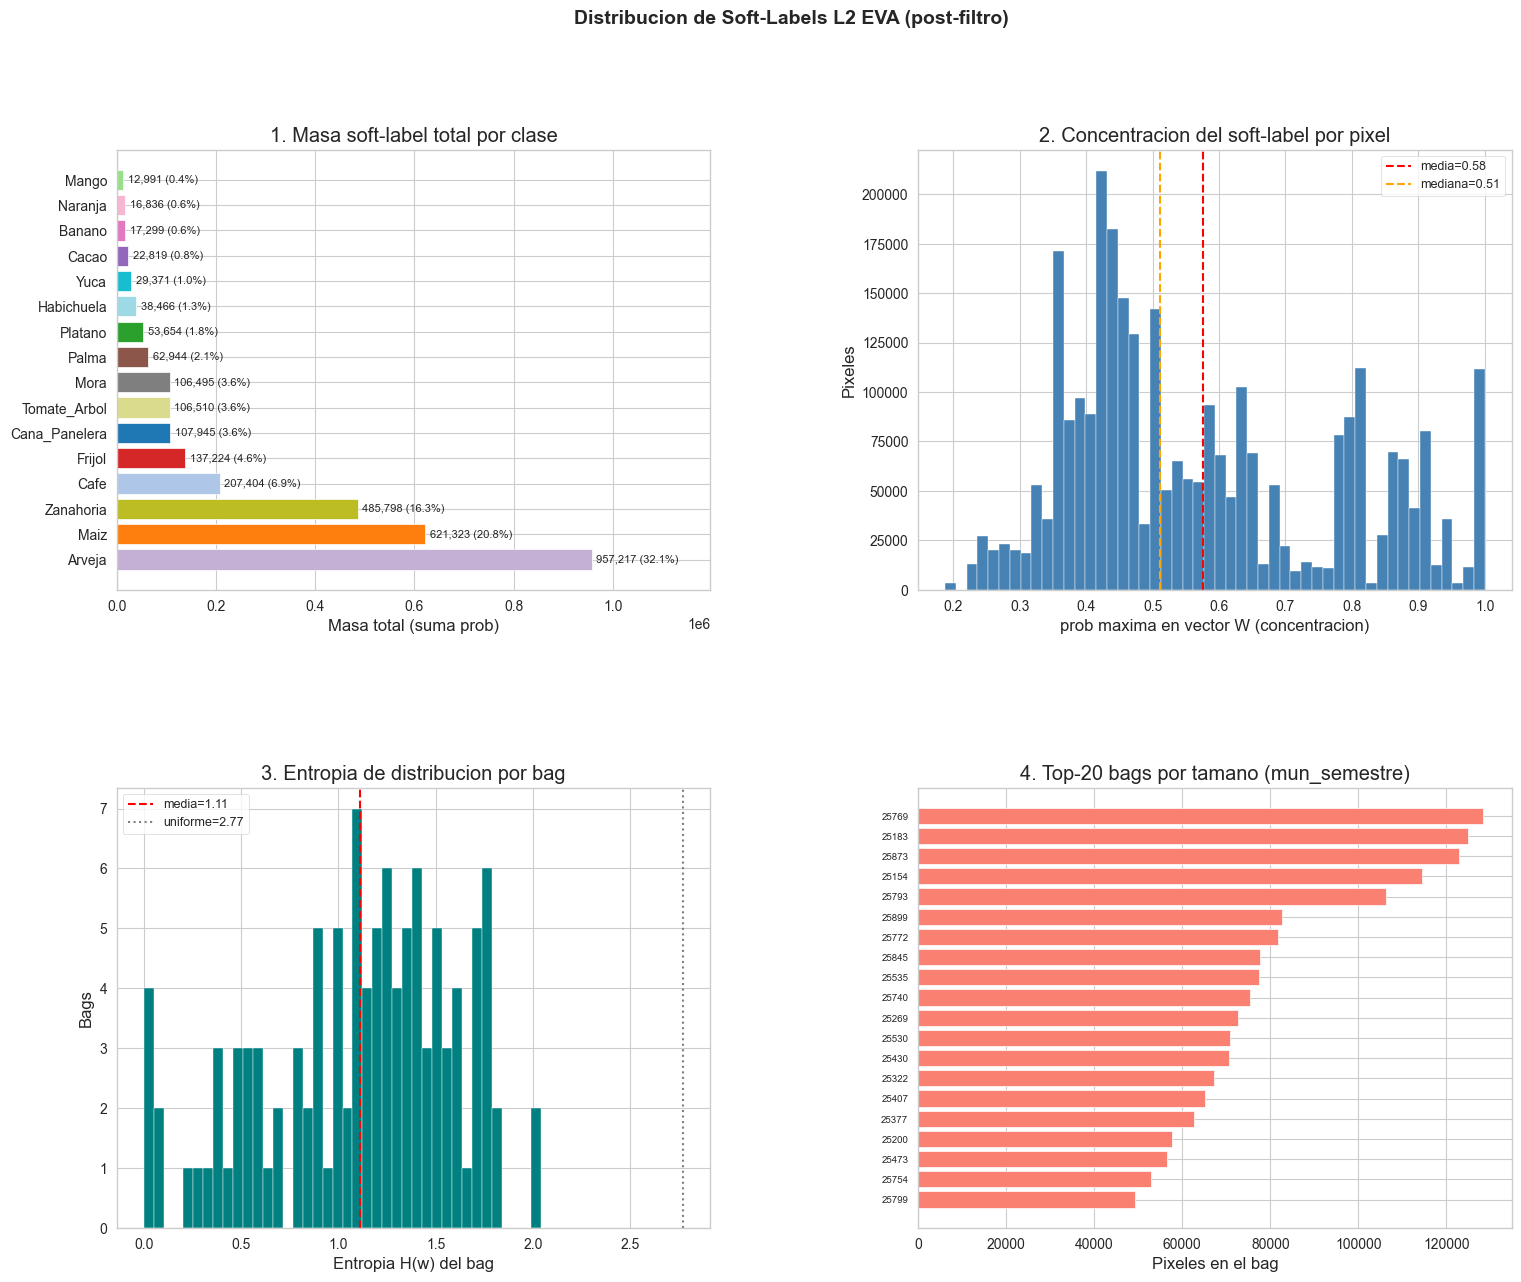

Resumen estadistico W_norm:
  Pixeles: 2,984,296   Clases: 16
  Entropia media por bag: 1.113  (max uniforme: 2.773)
  Prob maxima media (concentracion): 0.575
  Bags donde prob_max > 0.7 (casi one-hot): 26.7% de pixeles
  Bags donde prob_max < 0.4 (muy difuso): 19.1% de pixeles


In [87]:
# === Visualizacion: distribucion de soft-labels en L2 ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import scipy.stats as stats

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── 1. Masa total por clase (suma de prob_<clase> sobre todos los pixeles) ──
ax1 = fig.add_subplot(gs[0, 0])
masa = W_norm.sum(axis=0)
orden = np.argsort(masa)[::-1]
colores = plt.cm.tab20(np.linspace(0, 1, len(CLASES_FINALES)))
bars = ax1.barh([CLASES_FINALES[i] for i in orden], masa[orden], color=[colores[i] for i in orden])
ax1.set_xlabel("Masa total (suma prob)")
ax1.set_title("1. Masa soft-label total por clase")
for bar, val in zip(bars, masa[orden]):
    ax1.text(bar.get_width() + masa.max()*0.01, bar.get_y() + bar.get_height()/2,
             f"{val:,.0f} ({val/masa.sum()*100:.1f}%)", va="center", fontsize=8)
ax1.set_xlim(0, masa.max() * 1.25)

# ── 2. Distribucion de la probabilidad maxima por pixel (confianza del bag) ──
ax2 = fig.add_subplot(gs[0, 1])
p_max = W_norm.max(axis=1)
ax2.hist(p_max, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
ax2.axvline(p_max.mean(), color="red", linestyle="--", label=f"media={p_max.mean():.2f}")
ax2.axvline(np.median(p_max), color="orange", linestyle="--", label=f"mediana={np.median(p_max):.2f}")
ax2.set_xlabel("prob maxima en vector W (concentracion)")
ax2.set_ylabel("Pixeles")
ax2.set_title("2. Concentracion del soft-label por pixel")
ax2.legend(fontsize=9)

# ── 3. Entropia por bag ──
ax3 = fig.add_subplot(gs[1, 0])
bag_idx = {}
for i, b in enumerate(df_l2.index):
    bid = df_l2.iloc[i]["_bag_id"]
    bag_idx.setdefault(bid, []).append(i)

entropias = []
bag_sizes = []
for bid, idxs in bag_idx.items():
    w = W_norm[idxs[0]]  # todos tienen el mismo w
    h = stats.entropy(w + 1e-10)
    entropias.append(h)
    bag_sizes.append(len(idxs))

entropias = np.array(entropias)
bag_sizes  = np.array(bag_sizes)
H_max = np.log(len(CLASES_FINALES))
ax3.hist(entropias, bins=40, color="teal", edgecolor="white", linewidth=0.3)
ax3.axvline(entropias.mean(), color="red", linestyle="--", label=f"media={entropias.mean():.2f}")
ax3.axvline(H_max, color="gray", linestyle=":", label=f"uniforme={H_max:.2f}")
ax3.set_xlabel("Entropia H(w) del bag")
ax3.set_ylabel("Bags")
ax3.set_title("3. Entropia de distribucion por bag")
ax3.legend(fontsize=9)

# ── 4. Pixeles por bag (top-20 bags mas grandes) ──
ax4 = fig.add_subplot(gs[1, 1])
bag_list = sorted(bag_idx.items(), key=lambda x: len(x[1]), reverse=True)[:20]
labels = [b for b, _ in bag_list]
sizes  = [len(v) for _, v in bag_list]
ax4.barh(labels[::-1], sizes[::-1], color="salmon")
ax4.set_xlabel("Pixeles en el bag")
ax4.set_title("4. Top-20 bags por tamano (mun_semestre)")
ax4.tick_params(axis="y", labelsize=7)

plt.suptitle("Distribucion de Soft-Labels L2 EVA (post-filtro)", fontsize=14, fontweight="bold")
plt.show()

print(f"Resumen estadistico W_norm:")
print(f"  Pixeles: {W_norm.shape[0]:,}   Clases: {W_norm.shape[1]}")
print(f"  Entropia media por bag: {entropias.mean():.3f}  (max uniforme: {H_max:.3f})")
print(f"  Prob maxima media (concentracion): {p_max.mean():.3f}")
print(f"  Bags donde prob_max > 0.7 (casi one-hot): {(p_max > 0.7).mean()*100:.1f}% de pixeles")
print(f"  Bags donde prob_max < 0.4 (muy difuso): {(p_max < 0.4).mean()*100:.1f}% de pixeles")


In [88]:
# === Codificacion ciclica del semestre + identificacion de features ===
YEAR_MIN, YEAR_MAX = 2020, 2024  # alineado con config.py (corte 2024A)

def encode_semestre_cyclic(df):
    df = df.copy()
    year = df['semestre'].str[:4].astype(int)
    sem = df['semestre'].str[4].map({'A': 0, 'B': 1})
    df['semestre_cos'] = np.cos(np.pi * sem).astype(np.float32)
    df['year_norm'] = ((year - YEAR_MIN) / max(YEAR_MAX - YEAR_MIN, 1)).astype(np.float32)
    return df

df_l2 = encode_semestre_cyclic(df_l2)

# Columnas a EXCLUIR: ids, target, soft labels, columnas auxiliares
EXCLUDE_COLS = [
    'pixel_id', 'x', 'y', 'cod_mun', 'semestre',
    'cultivo', 'cultivo_id', 'cultivo_id_final', 'confianza',
    'fuente', 'rendimiento_tha', '_bag_id',
    'temperatura_max', 'temperatura_min',
    's2_savi_media', 's2_savi_max', 's2_savi_std',
    'ndvi_max',
    'semestre_cos',   # <-- agregar
    'year_norm',      # <-- agregar
]
EXCLUDE_COLS += [c for c in df_l2.columns if c.startswith('prob_')]

feature_cols = [c for c in df_l2.columns if c not in EXCLUDE_COLS]
print(f"Features para el modelo ({len(feature_cols)}):")
for c in feature_cols:
    print(f"  {c}")


Features para el modelo (39):
  elevacion
  pendiente
  twi
  sg_phh2o
  sg_soc
  sg_nitrogen
  sg_cec
  sg_bdod
  sg_clay
  sg_sand
  sg_silt
  igac_fertilidad
  igac_fosforo
  igac_ph
  igac_potasio
  igac_vocacion
  piso_termico
  indice_fertilidad
  aspecto_sin
  aspecto_cos
  temperatura_media
  humedad_media
  chirps_acum
  s2_ndvi_media
  s2_ndvi_max
  s2_ndvi_std
  s2_gndvi_media
  s2_gndvi_max
  s2_gndvi_std
  s2_msavi_media
  s2_msavi_max
  s2_msavi_std
  s2_bsi_media
  s2_bsi_max
  s2_bsi_std
  amplitud_termica
  anomalia_precip
  ndvi_integral
  indice_aridez


In [89]:
# === Split train/valid/test por municipio (GroupShuffleSplit) ===
# Test 15% / Valid 15% / Train 70%
groups = df_l2['cod_mun'].astype(int).values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
idx_trv, idx_test = next(gss1.split(df_l2, groups=groups))

g_trv = groups[idx_trv]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15/0.85, random_state=42)
idx_tr_local, idx_va_local = next(gss2.split(idx_trv, groups=g_trv))
idx_train = idx_trv[idx_tr_local]
idx_valid = idx_trv[idx_va_local]

print(f"Train: {len(idx_train):,} pixeles ({len(set(groups[idx_train]))} municipios)")
print(f"Valid: {len(idx_valid):,} pixeles ({len(set(groups[idx_valid]))} municipios)")
print(f"Test:  {len(idx_test):,} pixeles ({len(set(groups[idx_test]))} municipios)")

# Verificacion: sin overlap de municipios entre splits
mun_tr = set(groups[idx_train])
mun_va = set(groups[idx_valid])
mun_te = set(groups[idx_test])
assert len(mun_tr & mun_va) == 0 and len(mun_tr & mun_te) == 0 and len(mun_va & mun_te) == 0
print("OK: sin interseccion de municipios entre train/valid/test")


Train: 2,049,632 pixeles (77 municipios)
Valid: 328,528 pixeles (17 municipios)
Test:  606,136 pixeles (17 municipios)
OK: sin interseccion de municipios entre train/valid/test


In [91]:
# === Preprocesador (StandardScaler para todas las features numericas) ===
#X_full = df_l2[feature_cols].values
X_full = df_l2[feature_cols].values.copy()
y_full = df_l2['cultivo_id_final'].values
W_full = W_norm  # (N, 11) ya renormalizado

# Sustituir NaN por la mediana de cada columna (sklearn no acepta NaN en muchos casos)
for j, c in enumerate(feature_cols):
    col = X_full[:, j]
    if np.isnan(col).any():
        med = np.nanmedian(col)
        X_full[np.isnan(col), j] = med

scaler = StandardScaler()
X_train = scaler.fit_transform(X_full[idx_train])
X_valid = scaler.transform(X_full[idx_valid])
X_test  = scaler.transform(X_full[idx_test])

y_train = y_full[idx_train]
y_valid = y_full[idx_valid]
y_test  = y_full[idx_test]

W_train = W_full[idx_train]
W_valid = W_full[idx_valid]
W_test  = W_full[idx_test]

# Bag ids (cod_mun + semestre concatenados como string)
bag_train = df_l2.iloc[idx_train]['_bag_id'].values
bag_valid = df_l2.iloc[idx_valid]['_bag_id'].values
bag_test  = df_l2.iloc[idx_test]['_bag_id'].values

print(f"X_train: {X_train.shape}  W_train: {W_train.shape}  bags_train: {len(set(bag_train))}")
print(f"X_valid: {X_valid.shape}  W_valid: {W_valid.shape}  bags_valid: {len(set(bag_valid))}")
print(f"X_test:  {X_test.shape}   W_test:  {W_test.shape}   bags_test:  {len(set(bag_test))}")


X_train: (2049632, 39)  W_train: (2049632, 16)  bags_train: 77
X_valid: (328528, 39)  W_valid: (328528, 16)  bags_valid: 17
X_test:  (606136, 39)   W_test:  (606136, 16)   bags_test:  17


---
## 4. Modelo L2 LLP-Co (PyTorch + Sinkhorn-Knopp)

Implementación adaptada del Algoritmo 1 del paper (La Rosa et al. 2022).

**Componentes:**
- `MLPEncoder`: 4 capas (256→128→64→1024) con LayerNorm/GELU/Dropout, salida normalizada L2.
- `Prototypes`: K=11 vectores entrenables en ℝ^{1024}.
- `FeatureAugmenter`: dropout 0.2 + ruido gaussiano σ=0.05 → 2 vistas por pixel.
- `sinkhorn_knopp`: solver OT con regularización entrópica ε=0.05, 5 iteraciones.
- `swap_loss`: pérdida cruzada intercambiada entre vistas (eq. 7-9 del paper).

**Bag size:** todos los píxeles del municipio-semestre se usan en cada paso de gradiente.


In [103]:
# === Modulos de PyTorch ===

class MLPEncoder(nn.Module):
    """Encoder tabular: features -> embedding 1024 normalizado L2."""
    def __init__(self, n_features, hidden_dims=(256, 128, 64), emb_dim=1024, dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, emb_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        z = self.net(x)
        z = F.normalize(z, dim=-1)  # esfera unitaria
        return z


class Prototypes(nn.Module):
    """K prototipos entrenables en ℝ^{emb_dim}."""
    def __init__(self, K, emb_dim=1024):
        super().__init__()
        self.V = nn.Parameter(torch.randn(K, emb_dim))

    def normed(self):
        return F.normalize(self.V, dim=-1)

    def forward(self, z):
        # cosine similarity: (N, emb) x (emb, K) -> (N, K)
        return z @ self.normed().T


def augment_features(X, p_drop=0.2, sigma=0.05):
    """Genera una vista aumentada: feature dropout + ruido gaussiano."""
    mask = (torch.rand_like(X) > p_drop).float()
    noise = torch.randn_like(X) * sigma
    return X * mask + noise


#@torch.no_grad()
#def sinkhorn_knopp(scores, w, n_iter=5, eps=0.05):
#    """
#    scores: (n, K) similitudes de prototipos
#    w:      (K,)  proporciones del bag (suma 1)
#    Devuelve Q (n, K) con filas que suman 1 y columnas con masa proporcional a w*n.
#    """
#    n, K = scores.shape
#    Q = torch.exp(scores / eps).clamp(min=1e-8)  # (n, K)
#    target_col = (w * n).clamp(min=1e-8)         # (K,)
#    target_row = torch.ones(n, device=Q.device)  # (n,)#

#    for _ in range(n_iter):
#        # Normalizar columnas
#        Q = Q * (target_col.unsqueeze(0) / Q.sum(dim=0, keepdim=True).clamp(min=1e-8))
#        # Normalizar filas
#        Q = Q * (target_row.unsqueeze(1) / Q.sum(dim=1, keepdim=True).clamp(min=1e-8))
#    return Q

@torch.no_grad()
def sinkhorn_knopp(scores, w, n_iter=5, eps=0.01):
    """Transporte Óptimo con truco de estabilidad numérica (resta el max)."""
    n, K = scores.shape
    scores = scores - scores.max(dim=1, keepdim=True).values  # <-- TRUCO VITAL
    Q = torch.exp(scores / eps).clamp(min=1e-8)  
    target_col = (w * n).clamp(min=1e-8)         
    target_row = torch.ones(n, device=Q.device)  

    for _ in range(n_iter):
        Q = Q * (target_col.unsqueeze(0) / Q.sum(dim=0, keepdim=True).clamp(min=1e-8))
        Q = Q * (target_row.unsqueeze(1) / Q.sum(dim=1, keepdim=True).clamp(min=1e-8))
    return Q


def swap_loss(p_s, p_t, q_s, q_t):
    """Pérdida cruzada simplificada."""
    loss_st = -(q_s * torch.log(p_t.clamp(min=1e-8))).sum(dim=-1).mean()
    loss_ts = -(q_t * torch.log(p_s.clamp(min=1e-8))).sum(dim=-1).mean()
    return loss_st + loss_ts

print("Modulos LLP-Co definidos.")


Modulos LLP-Co definidos.


In [104]:
# === Estructuras para bags dinamicos (LLP-Co) ===
def build_bag_index(bag_ids):
    idx_by_bag = collections.defaultdict(list)
    for i, b in enumerate(bag_ids):
        idx_by_bag[b].append(i)
    return {b: np.asarray(v, dtype=np.int64) for b, v in idx_by_bag.items()}

def compute_w_mun(W_split, bag_index):
    w_mun = {}
    for mun, idx in bag_index.items():
        w = W_split[idx].mean(axis=0)
        w_mun[mun] = (w / w.sum()).astype(np.float32)
    return w_mun

#def sample_bag(idx_pool, bag_size, rng):
#    if len(idx_pool) >= bag_size:
#        return rng.choice(idx_pool, bag_size, replace=False)
#    return rng.choice(idx_pool, bag_size, replace=True)

def swap_loss(p_s, p_t, q_s, q_t):
    """Pérdida cruzada simplificada."""
    loss_st = -(q_s * torch.log(p_t.clamp(min=1e-8))).sum(dim=-1).mean()
    loss_ts = -(q_t * torch.log(p_s.clamp(min=1e-8))).sum(dim=-1).mean()
    return loss_st + loss_ts


bag_index_tr = build_bag_index(bag_train)
bag_index_va = build_bag_index(bag_valid)
W_mun_tr = compute_w_mun(W_train, bag_index_tr)
W_mun_va = compute_w_mun(W_valid, bag_index_va)

print(f"Bags train: {len(bag_index_tr)} municipios | bags valid: {len(bag_index_va)} municipios")
sizes_tr = [len(v) for v in bag_index_tr.values()]
print(f"Pool train: min={min(sizes_tr)}, median={int(np.median(sizes_tr))}, max={max(sizes_tr)}")
# print(f"Municipios con pool < BAG_SIZE (usaran muestreo con reemplazo): ")
# print(f"{sum(s < BAG_SIZE for s in sizes_tr)}")


Bags train: 77 municipios | bags valid: 17 municipios
Pool train: min=450, median=12332, max=128405


In [105]:
# === Configuracion de entrenamiento ===
N_FEATURES = X_train.shape[1]
K = K_FINAL         # 16 clases L2
EMB_DIM = 1024
TAU = 0.05
EPS_SK = 0.01
N_SINKHORN = 5
LR_INIT = 0.1
LR_MIN = 1e-5
WEIGHT_DECAY = 1e-6
WARMUP_EPOCHS = 5
TOTAL_EPOCHS = 200
P_DROP_AUG = 0.2
SIGMA_AUG = 0.05
FREEZE_PROTO_EPOCHS = 1     # prototipos congelados durante 1ra epoca
BAG_SIZE = 1024             # pixeles muestreados por municipio por epoch (= batch size del paper)
SEED = 42

print(f"Config LLP-Co: K={K}, emb={EMB_DIM}, lr={LR_INIT}->{LR_MIN}, "
      f"epocas={TOTAL_EPOCHS} (warmup={WARMUP_EPOCHS}), "
      f"sinkhorn iter={N_SINKHORN} eps={EPS_SK}, tau={TAU}")


Config LLP-Co: K=16, emb=1024, lr=0.1->1e-05, epocas=200 (warmup=5), sinkhorn iter=5 eps=0.01, tau=0.05


In [106]:
torch.manual_seed(SEED)
np.random.seed(SEED)

encoder = MLPEncoder(N_FEATURES, hidden_dims=(256, 128, 64), emb_dim=EMB_DIM, dropout=0.2).to(DEVICE)
prototypes = Prototypes(K, EMB_DIM).to(DEVICE)

optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(prototypes.parameters()),
    lr=3e-4, weight_decay=WEIGHT_DECAY
)

def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return LR_INIT * (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(TOTAL_EPOCHS - WARMUP_EPOCHS, 1)
    return LR_MIN + 0.5 * (LR_INIT - LR_MIN) * (1 + np.cos(np.pi * progress))

X_train_t = torch.from_numpy(X_train).float()
X_valid_t = torch.from_numpy(X_valid).float()

# Precalcular tensores de proporciones municipio para train y valid
W_mun_tr_t = {mun: torch.from_numpy(w).float().to(DEVICE) for mun, w in W_mun_tr.items()}
W_mun_va_t = {mun: torch.from_numpy(w).float().to(DEVICE) for mun, w in W_mun_va.items()}

bag_ids_tr_list = list(bag_index_tr.keys())
history = {"epoch": [], "lr": [], "loss_train": [], "kl_valid": []}

print("Iniciando entrenamiento LLP-Co (bags dinamicos)...")
print(f"  {len(bag_ids_tr_list)} municipios procesados por epoch (Max pixeles/bag: {BAG_SIZE})")
t0 = time.time()

for epoch in range(TOTAL_EPOCHS):
    lr = get_lr(epoch)
    for g in optimizer.param_groups:
        g["lr"] = lr

    for p in prototypes.parameters():
        p.requires_grad = (epoch >= FREEZE_PROTO_EPOCHS)

    # Nuevo orden aleatorio de municipios + nueva semilla de muestreo por epoch
    rng = np.random.RandomState(SEED + epoch)
    rng.shuffle(bag_ids_tr_list)

    encoder.train()
    prototypes.train()
    loss_acc = 0.0
    n_bags_seen = 0

    for b in bag_ids_tr_list:
        # Muestreo dinamico (si el pool es < BAG_SIZE, trae menos, nunca clona)
        idx = sample_bag(bag_index_tr[b], BAG_SIZE, rng)

        X_b = X_train_t[idx].to(DEVICE)       # (N_dinamico, F)
        w_b = W_mun_tr_t[b]                   # (K,) proporcion EVA municipio

        X_s = augment_features(X_b, P_DROP_AUG, SIGMA_AUG)
        X_t = augment_features(X_b, P_DROP_AUG, SIGMA_AUG)

        z_s = encoder(X_s)
        z_t = encoder(X_t)

        # 1. Generar similitudes crudas (cosine similarities)
        scores_s = prototypes(z_s)
        scores_t = prototypes(z_t)

        # 2. RUTA SINKHORN: Inyectar las similitudes CRUDAS directamente
        q_s = sinkhorn_knopp(scores_s.detach(), w_b, n_iter=N_SINKHORN, eps=EPS_SK)
        q_t = sinkhorn_knopp(scores_t.detach(), w_b, n_iter=N_SINKHORN, eps=EPS_SK)

        q_s = q_s / q_s.sum(dim=1, keepdim=True).clamp(min=1e-8)
        q_t = q_t / q_t.sum(dim=1, keepdim=True).clamp(min=1e-8)

        # 3. RUTA SWAP LOSS: Convertir a probabilidades base usando TAU
        p_s = F.softmax(scores_s / TAU, dim=-1)
        p_t = F.softmax(scores_t / TAU, dim=-1)

        # 4. Calcular la pérdida enviando los tensores correctos
        loss = swap_loss(p_s, p_t, q_s, q_t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_acc += loss.item()
        n_bags_seen += 1

    # Validacion: KL usando todos los pixeles del municipio (sin submuestreo)
    encoder.eval()
    prototypes.eval()
    kl_acc, n_bags_val = 0.0, 0
    with torch.no_grad():
        for b, idx in bag_index_va.items():
            X_b = X_valid_t[idx].to(DEVICE)
            w_eva = W_mun_va_t[b]
            z = encoder(X_b)
            p = F.softmax(prototypes(z) / TAU, dim=-1).mean(dim=0)
            kl = (w_eva * (torch.log(w_eva.clamp(min=1e-8)) - torch.log(p.clamp(min=1e-8)))).sum().item()
            kl_acc += kl
            n_bags_val += 1

    loss_avg = loss_acc / max(n_bags_seen, 1)
    kl_avg = kl_acc / max(n_bags_val, 1)
    history["epoch"].append(epoch)
    history["lr"].append(lr)
    history["loss_train"].append(loss_avg)
    history["kl_valid"].append(kl_avg)

    print(f"Epoca {epoch+1:2d}/{TOTAL_EPOCHS}  lr={lr:.5f}  "
          f"loss_train={loss_avg:.4f}  KL_valid={kl_avg:.4f}  "
          f"({(time.time()-t0):.0f}s)")

print(f"Entrenamiento LLP-Co completado en {(time.time()-t0)/60:.1f} min.")

Iniciando entrenamiento LLP-Co (bags dinamicos)...
  77 municipios procesados por epoch (Max pixeles/bag: 1024)
Epoca  1/200  lr=0.02000  loss_train=5.8234  KL_valid=1.2672  (4s)
Epoca  2/200  lr=0.04000  loss_train=5.3441  KL_valid=1.0242  (7s)
Epoca  3/200  lr=0.06000  loss_train=4.7766  KL_valid=1.2214  (11s)
Epoca  4/200  lr=0.08000  loss_train=4.6399  KL_valid=1.0175  (15s)
Epoca  5/200  lr=0.10000  loss_train=4.6316  KL_valid=1.0853  (19s)
Epoca  6/200  lr=0.10000  loss_train=4.0424  KL_valid=1.1115  (22s)
Epoca  7/200  lr=0.09999  loss_train=4.1102  KL_valid=1.0123  (26s)
Epoca  8/200  lr=0.09997  loss_train=3.8839  KL_valid=1.0112  (30s)
Epoca  9/200  lr=0.09994  loss_train=3.8498  KL_valid=0.8636  (33s)
Epoca 10/200  lr=0.09990  loss_train=3.6873  KL_valid=0.9727  (37s)
Epoca 11/200  lr=0.09984  loss_train=3.8005  KL_valid=0.9362  (41s)
Epoca 12/200  lr=0.09977  loss_train=3.5958  KL_valid=1.0168  (45s)
Epoca 13/200  lr=0.09968  loss_train=3.5956  KL_valid=1.0719  (48s)
Epoca 

Pesos guardados en checkpoints\l2_llp_co.pt


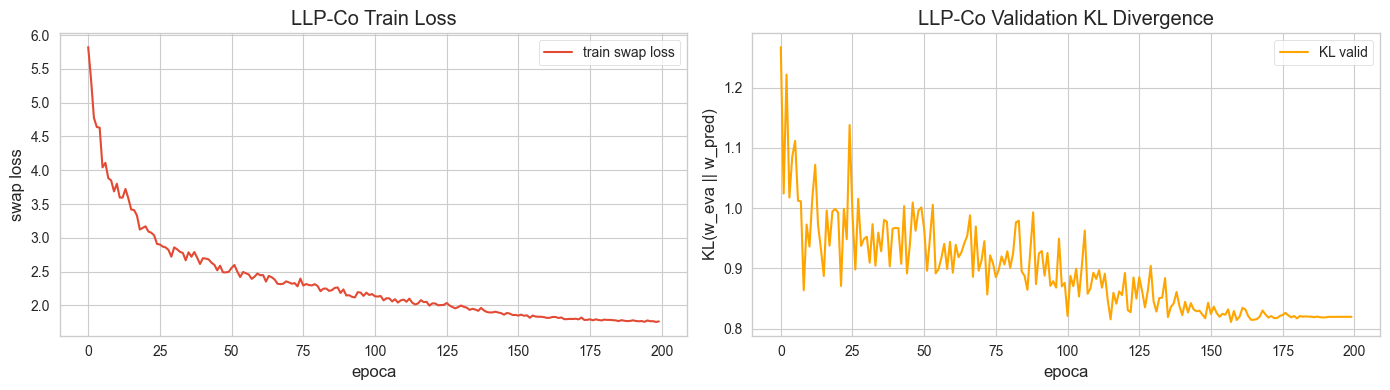

In [107]:
# === Persistir pesos del modelo L2 LLP-Co ===
torch.save({
    'encoder_state': encoder.state_dict(),
    'prototypes_state': prototypes.state_dict(),
    'config': {
        'n_features': N_FEATURES, 'K': K, 'emb_dim': EMB_DIM,
        'tau': TAU, 'eps_sk': EPS_SK,
    },
    'feature_cols': feature_cols,
    'classes': CLASES_FINALES,
    'history': history,
}, CKPT_DIR / 'l2_llp_co.pt')
print(f"Pesos guardados en {CKPT_DIR / 'l2_llp_co.pt'}")

# Plot de la curva de loss
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['epoch'], history['loss_train'], label='train swap loss')
axes[0].set_xlabel('epoca'); axes[0].set_ylabel('swap loss')
axes[0].set_title('LLP-Co Train Loss')
axes[0].legend()

axes[1].plot(history['epoch'], history['kl_valid'], label='KL valid', color='orange')
axes[1].set_xlabel('epoca'); axes[1].set_ylabel('KL(w_eva || w_pred)')
axes[1].set_title('LLP-Co Validation KL Divergence')
axes[1].legend()
plt.tight_layout()


---
## 4. Evaluacion del modelo LLP-Co

Tres metricas complementarias:

1. **Metrica de bag** - `KL(w_eva || w_pred_promedio)` por municipio. Mide si las proporciones predichas a nivel municipio coinciden con las reportadas por EVA. Es la metrica nativa de LLP.

2. **Metrica de pixel** - `F1 macro` y matriz de confusion usando como pseudo-ground-truth `argmax(W_eva)`. Imperfecta (penaliza predicciones soft correctas) pero util como sanity check.

3. **Analisis de prototipos** - similitud coseno entre los K vectores prototipo. Off-diagonal cercana a 0 indica buena separabilidad de clases en el espacio embebido.

### 5.1 Predicciones del modelo


In [ ]:
# === Predicciones LLP-Co en VALID y TEST ===
@torch.no_grad()
def predict_llp_co(X_arr, batch_size=4096):
    encoder.eval(); prototypes.eval()
    out = []
    for i in range(0, len(X_arr), batch_size):
        Xt = torch.from_numpy(X_arr[i:i+batch_size]).float().to(DEVICE)
        z = encoder(Xt)
        p = F.softmax(prototypes(z) / TAU, dim=-1).cpu().numpy()
        out.append(p)
    return np.vstack(out)

P_llp_va = predict_llp_co(X_valid)
P_llp_te = predict_llp_co(X_test)

print(f"Probabilidades LLP-Co valid: {P_llp_va.shape}")
print(f"Probabilidades LLP-Co test:  {P_llp_te.shape}")


Probabilidades LLP-Co valid: (328528, 16)
Probabilidades LLP-Co test:  (606136, 16)


In [ ]:
# === Metrica de bag: KL(w_eva || w_pred) por municipio ===
def kl_per_bag(P, bag_index, w_mun_dict, eps=1e-8):
    kls = {}
    for b, idx in bag_index.items():
        w_eva = w_mun_dict[b]
        p_pred = P[idx].mean(axis=0)
        kl = (w_eva * (np.log(w_eva + eps) - np.log(p_pred + eps))).sum()
        kls[b] = kl
    return kls

kl_llp_va = kl_per_bag(P_llp_va, bag_index_va, W_mun_va)
kl_arr = np.array(list(kl_llp_va.values()))

print(f"KL(w_eva || w_pred) en valid (por municipio):")
print(f"  mean   = {kl_arr.mean():.4f}")
print(f"  median = {np.median(kl_arr):.4f}")
print(f"  p25    = {np.percentile(kl_arr, 25):.4f}")
print(f"  p75    = {np.percentile(kl_arr, 75):.4f}")
print(f"  max    = {kl_arr.max():.4f}")
print()
print("Top-5 municipios con peor KL (mayor divergencia):")
sorted_kl = sorted(kl_llp_va.items(), key=lambda x: -x[1])
for mun, kl in sorted_kl[:5]:
    print(f"  mun={mun}  KL={kl:.4f}")


KL(w_eva || w_pred) en valid (por municipio):
  mean   = 0.8019
  median = 0.6130
  p25    = 0.4494
  p75    = 0.9108
  max    = 3.0070

Top-5 municipios con peor KL (mayor divergencia):
  mun=25524  KL=3.0070
  mun=25653  KL=1.3502
  mun=25281  KL=1.2071
  mun=25178  KL=0.9843
  mun=25426  KL=0.9108


In [ ]:
# === Metrica pixel: F1 macro vs argmax(W_eva) ===
y_va_pseudo = W_valid.argmax(axis=1)
pred_llp = P_llp_va.argmax(axis=1)

print("=" * 60)
print("LLP-Co vs pseudo-ground-truth (argmax W_eva):")
print("=" * 60)
print(f"  Accuracy:    {accuracy_score(y_va_pseudo, pred_llp):.4f}")
print(f"  F1 macro:    {f1_score(y_va_pseudo, pred_llp, average='macro', zero_division=0):.4f}")
print(f"  F1 micro:    {f1_score(y_va_pseudo, pred_llp, average='micro', zero_division=0):.4f}")
print(f"  F1 weighted: {f1_score(y_va_pseudo, pred_llp, average='weighted', zero_division=0):.4f}")


LLP-Co vs pseudo-ground-truth (argmax W_eva):
  Accuracy:    0.2837
  F1 macro:    0.1727
  F1 micro:    0.2837
  F1 weighted: 0.3125


In [ ]:
# === Reporte detallado por clase (LLP-Co) ===
print(classification_report(
    y_va_pseudo, pred_llp,
    labels=np.arange(K_FINAL), target_names=CLASES_FINALES,
    zero_division=0
))


               precision    recall  f1-score   support

Cana_Panelera       0.31      0.25      0.28     33286
         Cafe       0.43      0.30      0.35     61459
         Maiz       0.54      0.37      0.44    115449
      Platano       0.18      0.18      0.18      2432
        Mango       0.36      0.47      0.40      4464
       Frijol       0.21      0.26      0.23     29525
        Cacao       0.00      0.00      0.00         0
       Arveja       0.13      0.19      0.15     42928
        Palma       0.00      0.00      0.00         0
       Banano       0.09      0.04      0.06      1263
      Naranja       0.00      0.00      0.00         0
         Mora       0.00      0.00      0.00         0
    Zanahoria       0.17      0.19      0.18     21138
 Tomate_Arbol       0.02      0.06      0.03      6945
         Yuca       0.13      0.09      0.11      9639
   Habichuela       0.00      0.00      0.00         0

     accuracy                           0.28    328528
    macr

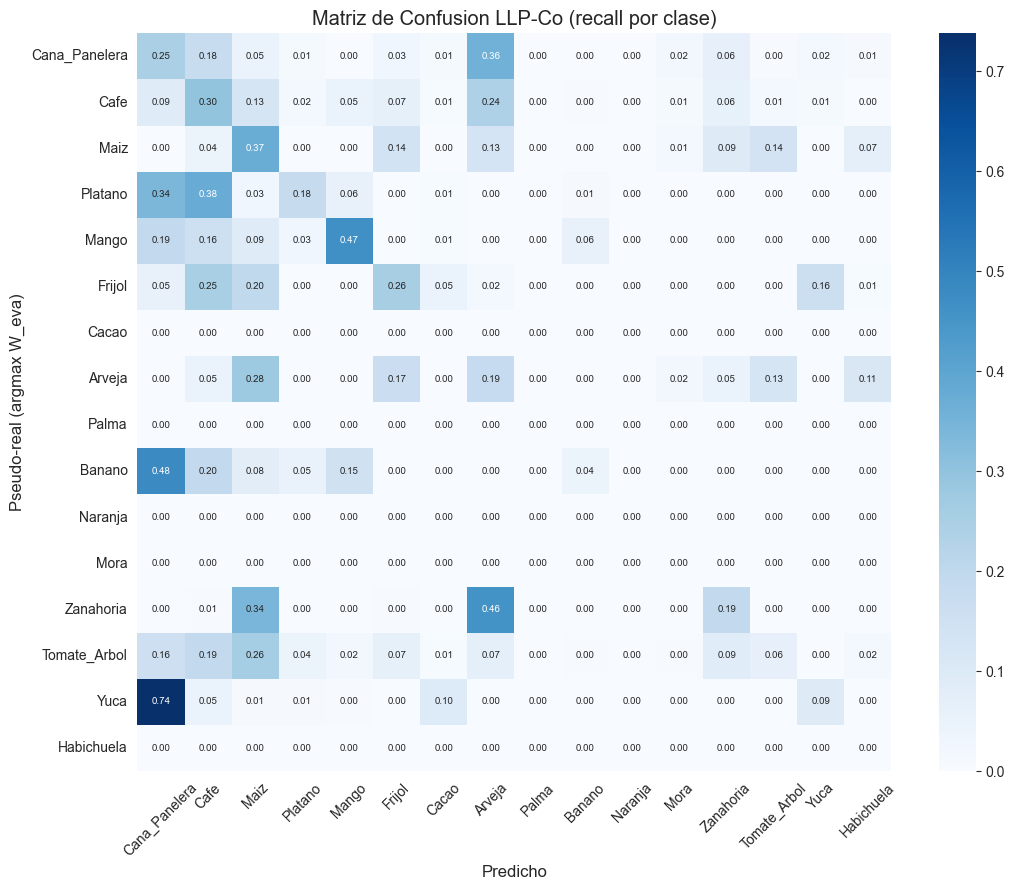

In [ ]:
# === Matriz de confusion (LLP-Co) ===
fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_va_pseudo, pred_llp, labels=np.arange(K_FINAL), normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            xticklabels=CLASES_FINALES, yticklabels=CLASES_FINALES,
            cbar=True, annot_kws={'size': 7})
ax.set_title('Matriz de Confusion LLP-Co (recall por clase)')
ax.set_xlabel('Predicho'); ax.set_ylabel('Pseudo-real (argmax W_eva)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()


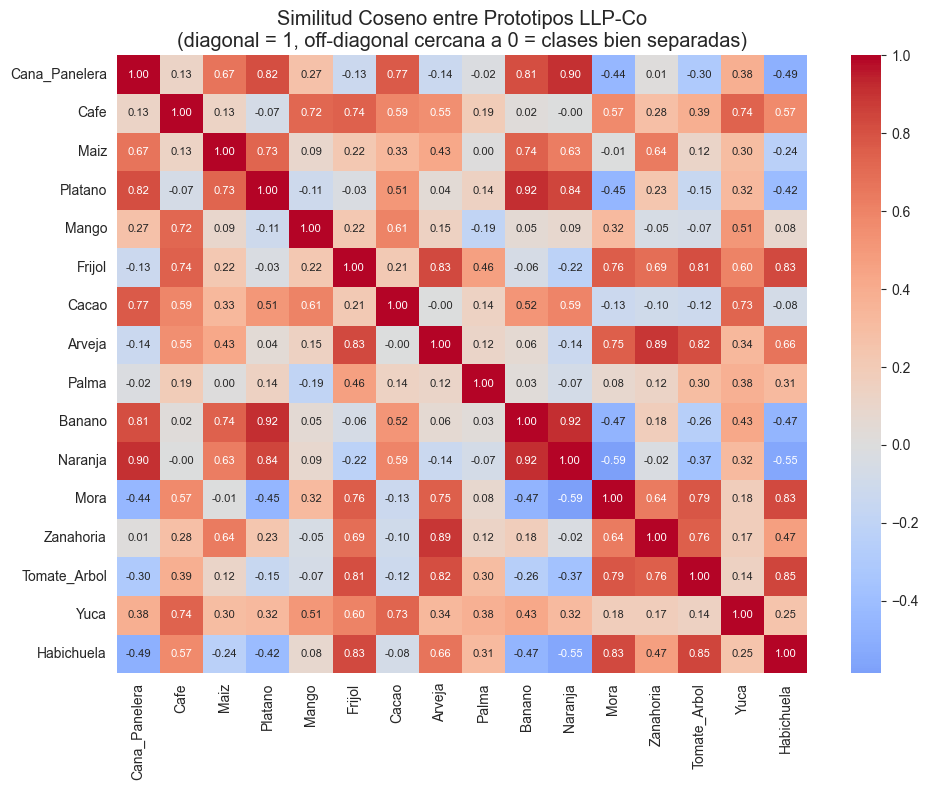

In [ ]:
# === Analisis de prototipos LLP-Co (similitud coseno entre prototipos) ===
with torch.no_grad():
    V = prototypes.normed().cpu().numpy()  # (K, emb)
sim = V @ V.T

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=CLASES_FINALES, yticklabels=CLASES_FINALES, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Similitud Coseno entre Prototipos LLP-Co\n(diagonal = 1, off-diagonal cercana a 0 = clases bien separadas)')
plt.tight_layout()


---
## 6. Conclusiones y siguientes pasos

### Resumen del modelo
- Encoder MLP + K=16 prototipos en R^{1024}.
- Bags dinamicos: cada municipio se samplea con `BAG_SIZE` pixeles aleatorios por epoch.
- Sinkhorn-Knopp con prior `w_mun` (proporcion EVA agregada del municipio).
- Pesos guardados en `checkpoints/l2_llp_co.pt`.

### Hiperparametros para afinar
En orden de impacto esperado:

| Hiperparametro | Rango sugerido | Efecto |
|----------------|----------------|--------|
| `BAG_SIZE`     | 1024 / 2048 / 4096 | Tamano de batch efectivo. Mas grande = OT mas estable, menos pasos por epoch. |
| `TAU`          | 0.05 / 0.1 / 0.2 | Temperatura softmax. Mas bajo = predicciones mas nitidas. |
| `EPS_SK`       | 0.01 / 0.05 / 0.1 | Regularizacion entropica de Sinkhorn. Mas alto = soluciones mas uniformes. |
| `LR_INIT`      | 0.05 / 0.1 / 0.3 | Tasa de aprendizaje SGD. |
| `TOTAL_EPOCHS` | 30 / 60 / 100   | Convergencia. KL_valid debe estabilizarse. |
| `EMB_DIM`      | 256 / 512 / 1024 | Capacidad del encoder. |
| `P_DROP_AUG` / `SIGMA_AUG` | 0.1-0.3 / 0.02-0.1 | Fuerza de la augmentacion de vistas. |

### Metricas a mirar al afinar
1. `KL_valid` (objetivo: bajar): debe descender y estabilizarse - si no baja, el modelo no respeta el prior.
2. `F1_macro` pixel (objetivo: subir): proxy de separabilidad por clase.
3. Similitud entre prototipos (objetivo: cercana a 0 off-diagonal): clases bien separadas.
